# User Experience Analysis

**Goals:**
1. Aggregate per-customer network experience (TCP, RTT, throughput, handset)
2. Top / bottom / most frequent values
3. Throughput & TCP by handset type
4. K-means (k=3) experience clusters

> Logic in `src/tellco_user_analytics/analysis/experience.py`

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from tellco_user_analytics.data.loader import load_xdr_experience_sessions
from tellco_user_analytics.analysis.experience import (
    EXPERIENCE_FEATURES,
    aggregate_experience,
    top_bottom_frequent,
    throughput_by_handset,
    tcp_retrans_by_handset,
    fit_experience_clusters,
    describe_experience_clusters,
    cluster_labels_from_stats,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Aggregate experience per customer

Missing numeric values → **mean**; handset type → **mode**; outliers → **mean** (IQR rule).

In [3]:
sessions = load_xdr_experience_sessions()
experience, cleaning_report = aggregate_experience(sessions, clean=True)

print(f"Customers: {len(experience):,}")
display(cleaning_report.head(10))
experience.head()

Customers: 106,856


,column,missing_replaced,outliers_replaced,replacement_value
0,_tcp_retrans,0,31276,"8,851,451.37"
1,_rtt_ms,0,14830,51.91
2,_throughput_kbps,0,13251,"7,535.19"
3,Avg RTT DL (ms),27829,7718,109.80
4,Avg RTT UL (ms),27812,8975,17.66
5,Avg Bearer TP DL (kbps),1,13235,"13,300.05"
6,Avg Bearer TP UL (kbps),1,21531,"1,770.43"
7,TCP DL Retrans. Vol (Bytes),88146,2525,"20,809,914.27"
8,TCP UL Retrans. Vol (Bytes),96649,1320,"759,658.66"
9,Handset Type,9559,0,Huawei B528S-23A


,customer_id,avg_tcp_retrans_bytes,avg_rtt_ms,avg_throughput_kbps,handset_type
0,"33,601,001,722.00",0.00,23.00,38.00,Huawei P20 Lite Huawei Nova 3E
1,"33,601,001,754.00",0.00,15.50,49.50,Apple iPhone 7 (A1778)
2,"33,601,002,511.00",0.00,0.00,48.50,Huawei B528S-23A
3,"33,601,007,832.00","1,066.00",42.00,124.00,Apple iPhone 5S (A1457)
4,"33,601,008,617.00","1,652,539.17",29.75,"3,783.34",Apple iPhone Se (A1723)


## 2. Top 10, bottom 10, most frequent values

In [4]:
metric_labels = {
    "avg_tcp_retrans_bytes": "TCP retransmission (bytes)",
    "avg_rtt_ms": "RTT (ms)",
    "avg_throughput_kbps": "Throughput (kbps)",
}

for col, label in metric_labels.items():
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    stats = top_bottom_frequent(experience, col, n=10)
    print("\nTop 10:")
    display(stats["top"])
    print("\nBottom 10:")
    display(stats["bottom"])
    print("\n10 most frequent values:")
    display(stats["most_frequent"].to_frame("count"))


TCP retransmission (bytes)

Top 10:


,customer_id,avg_tcp_retrans_bytes
0,"33,601,008,617.00","1,652,539.17"
1,"33,601,021,217.00","1,652,539.17"
2,"33,601,031,129.00","1,652,539.17"
3,"33,601,034,530.00","1,652,539.17"
4,"33,601,048,751.00","1,652,539.17"
5,"33,601,062,786.00","1,652,539.17"
6,"33,601,070,798.00","1,652,539.17"
7,"33,601,073,415.00","1,652,539.17"
8,"33,601,082,181.00","1,652,539.17"
9,"33,601,101,581.00","1,652,539.17"



Bottom 10:


,customer_id,avg_tcp_retrans_bytes
0,"33,601,001,722.00",0.00
1,"33,601,001,754.00",0.00
2,"33,601,002,511.00",0.00
3,"33,601,014,694.00",0.00
4,"33,601,021,045.00",0.00
5,"33,601,022,743.00",0.00
6,"33,601,024,291.00",0.00
7,"33,601,025,738.00",0.00
8,"33,601,027,208.00",0.00
9,"33,601,032,846.00",0.00



10 most frequent values:


...

,customer_id,avg_throughput_kbps
0,"33,664,402,022.00","18,226.90"
1,"33,768,288,172.00","18,226.50"
2,"33,669,415,292.00","18,225.50"
3,"33,662,110,507.00","18,223.00"
4,"33,658,079,262.00","18,221.67"
5,"33,658,030,175.00","18,219.50"
6,"33,750,964,155.00","18,218.50"
7,"33,762,053,453.00","18,218.25"
8,"33,650,867,375.00","18,217.50"
9,"33,650,944,835.00","18,217.00"



Bottom 10:


,customer_id,avg_throughput_kbps
0,"33,603,452,974.00",0.00
1,"33,604,131,582.00",0.00
2,"33,608,514,832.00",0.00
3,"33,608,752,702.00",0.00
4,"33,608,892,887.00",0.00
5,"33,609,847,664.00",0.00
6,"33,610,640,063.00",0.00
7,"33,611,523,366.00",0.00
8,"33,616,110,252.00",0.00
9,"33,616,605,202.00",0.00



10 most frequent values:


,count
avg_throughput_kbps,
"4,025.08",5659
"7,535.19",5551
7.50,2872
31.50,2138
48.50,1094
45.00,1062
49.00,1025
48.00,938
49.50,918


## 3. Experience by handset type

,mean,median,count
handset_type,,,
Lenovo Moto Z Play Vx12752445,"18,076.25","18,076.25",1
Samsung Galaxy A6 (Sm-A605F),"17,928.00","17,928.00",1
Lg-H791,"17,913.00","17,913.00",1
Sony Mobile Comm. Sony Xperia Z (C6603),"17,818.00","17,818.00",1
Oppo A33F,"17,461.00","17,461.00",1
Nubia Technology. M2 Play,"17,282.50","17,282.50",1
Samsung Galaxy J8 2018,"16,419.50","16,419.50",1
Tcl Communicatio. Alcatel Onetouch 5070D,"16,034.00","16,034.00",1
Huawei Bkl-Tl10,"16,015.50","16,015.50",1


,mean,median,count
handset_type,,,
Tp-Link Technolo. Archer Mr400,"1,652,539.17","1,652,539.17",5
Huawei Nova 3I Huawei P Smart+,"1,652,539.17","1,652,539.17",1
Xiaomi Communica. Mi 6,"1,652,539.17","1,652,539.17",2
Kvd Internationa. Doogee X5,"1,652,539.17","1,652,539.17",1
Kvd Internationa. Doogee Mix Lite,"1,652,539.17","1,652,539.17",1
Kenxinda V7,"1,652,539.17","1,652,539.17",1
Infinix Technolo. Infinix Hot Note,"1,652,539.17","1,652,539.17",1
Infinix Technolo. Hot 6,"1,652,539.17","1,652,539.17",1
Huawei Y7 Prime 2018 Huawei Y7 Pro 2018,"1,652,539.17","1,652,539.17",1


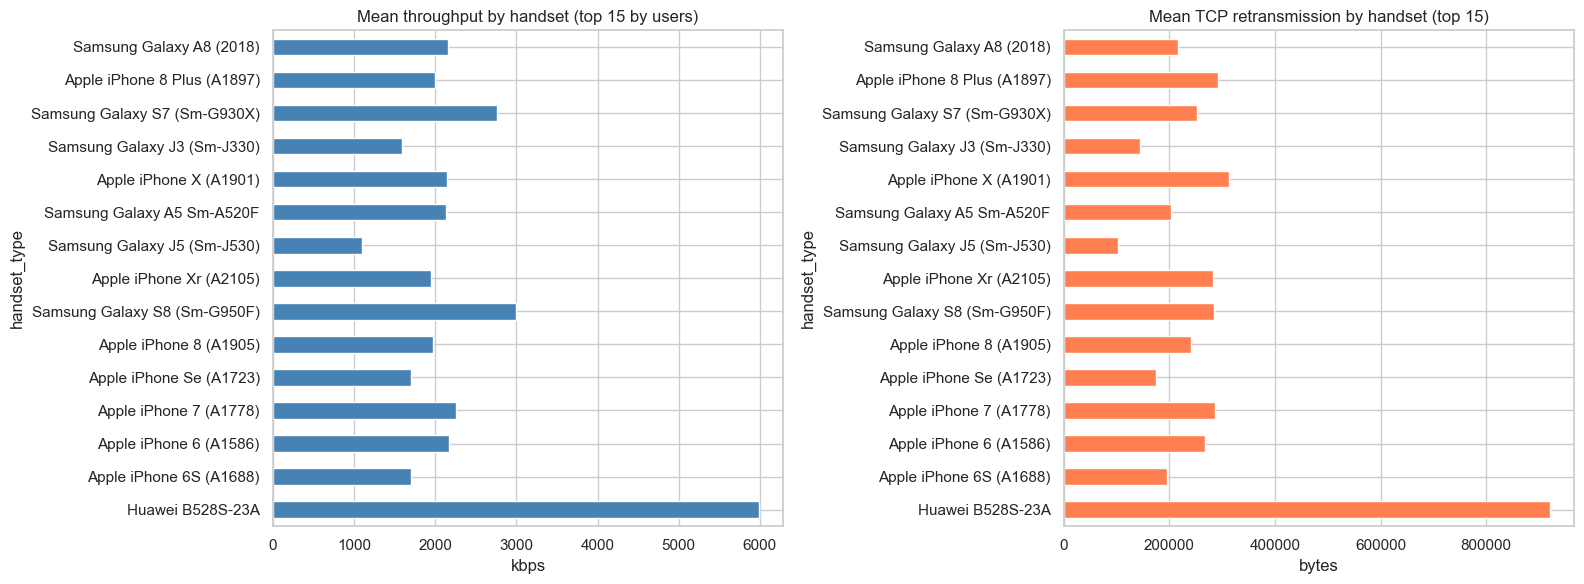

In [5]:
tp_handset = throughput_by_handset(experience)
tcp_handset = tcp_retrans_by_handset(experience)

# Top 15 handsets by user count for readable charts
top_handsets = tp_handset.nlargest(15, "count").index
tp_plot = tp_handset.loc[top_handsets]
tcp_plot = tcp_handset.loc[top_handsets]

display(tp_handset.head(15))
display(tcp_handset.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tp_plot["mean"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Mean throughput by handset (top 15 by users)")
axes[0].set_xlabel("kbps")

tcp_plot["mean"].plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Mean TCP retransmission by handset (top 15)")
axes[1].set_xlabel("bytes")
plt.tight_layout()
plt.show()

### Interpretation

**Throughput by handset**
- **Fastest segments (≥50 users):** Huawei mobile routers dominate — **E5180 (~8,305 kbps)**, **E5573/E5573B (~6,900–7,275 kbps)**, and **B528S-23A (~5,986 kbps)**. These are typically MiFi/home-router devices on sustained data sessions.
- **Slowest segments:** Legacy phones and dongles — **Zte Mf259 (~85 kbps)**, **iPhone 4/4S (~617–848 kbps)**, **Samsung Galaxy J5 (~1,101 kbps)**. Well below the network average (~**3,055 kbps**).
- **Largest installed base:** **Huawei B528S-23A** (17.3k users) delivers above-average throughput; **iPhone 6/6S** (6k+ each) sit at ~1,700–2,200 kbps with very low medians (~53–58 kbps), suggesting many light sessions mixed with a few heavy users.

**TCP retransmission by handset**
- **Highest TCP:** Same Huawei router family (**E5180 ~1.3M bytes**, **E5573 ~1.3M**, **B528S-23A ~920k**) — high retransmission here likely reflects **heavy data use**, not necessarily faulty hardware. These devices drive more bytes, so more retransmission volume is expected.
- **Lowest TCP (≥50 users):** Older/low-traffic Samsung models (**Sm-G389F ~33k**, **Galaxy J5 ~103k**) — fewer bytes transferred overall, so lower absolute retransmission.
- **Do not read TCP in isolation:** A handset with high throughput *and* high TCP may be a power-user router; a handset with **low throughput *and* elevated TCP** (relative to its traffic) is a stronger candidate for radio/firmware investigation.

**Business actions**
- **Compatibility / upgrade targets:** Prioritise outreach for **iPhone 4/4S, Galaxy J5, Zte Mf259** users — low throughput may indicate outdated devices or poor band support.
- **Capacity planning:** **Huawei B528S-23A + E-series routers** are the main throughput drivers — ensure network capacity and QoS policies account for this segment.
- **Data-quality note:** Mean imputation pulls many values to column means (visible as repeated medians e.g. 7,535 kbps / 1,652,539 bytes) — treat extreme handset rankings as directional, not exact.

## 4. Task 4.4 — K-means experience clusters (k=3)

Clusters use **StandardScaler** on TCP, RTT, and throughput (handset type excluded — categorical).

In [ ]:
cluster_result = fit_experience_clusters(experience, k=3)
clustered = cluster_result.data
cluster_stats = describe_experience_clusters(clustered)
labels = cluster_labels_from_stats(cluster_stats)

display(cluster_stats)

print("\nCluster descriptions:")
for cluster_id, text in sorted(labels.items()):
    n_users = (clustered["cluster"] == cluster_id).sum()
    print(f"  Cluster {cluster_id} ({n_users:,} users): {text}")

# Visualise cluster centroids (raw means)
cluster_means = clustered.groupby("cluster")[EXPERIENCE_FEATURES].mean()
cluster_means.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Mean experience metrics by cluster")
plt.ylabel("Value (original units)")
plt.tight_layout()
plt.show()